In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/clean_stock_data.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Ticker", "Date"])

df = df.dropna(subset=["Daily_Return"])

print(df.head())

        Date  Adj Close      Close       High        Low       Open   Volume  \
0 2015-01-05  59.577908  82.889999  82.919998  82.699997  82.739998  5820100   
1 2015-01-06  59.750416  83.129997  83.379997  83.029999  83.029999  3887600   
2 2015-01-07  59.786331  83.180000  83.279999  83.050003  83.139999  2433400   
3 2015-01-08  59.692890  83.050003  83.110001  82.970001  83.110001  1873400   
4 2015-01-09  59.793522  83.190002  83.290001  83.000000  83.010002  1646100   

  Ticker  Daily_Return  
0    BND      0.002904  
1    BND      0.002895  
2    BND      0.000602  
3    BND     -0.001563  
4    BND      0.001686  


DAILY RETURNS CHECK

In [2]:
df.groupby("Ticker")["Daily_Return"].describe()

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
BND,2887.0,-0.000034,0.003383,-0.054385,-0.001635,0.000119,0.001715,0.042201
SPY,2887.0,0.000507,0.011163,-0.109424,-0.003772,0.000603,0.005920,0.105019
TSLA,2887.0,0.001803,0.036018,-0.210628,-0.016643,0.001216,0.019456,0.226900


ANNUALIZED RETURN

In [4]:
annual_return = df.groupby("Ticker")["Daily_Return"].mean() * 252
print("Annualized Return:\n", annual_return)

Annualized Return:
 Ticker
BND    -0.008548
SPY     0.127746
TSLA    0.454239
Name: Daily_Return, dtype: float64


ANNUALIZED VOLATILITY

In [5]:
annual_vol = df.groupby("Ticker")["Daily_Return"].std() * np.sqrt(252)
print("Annualized Volatility:\n", annual_vol)

Annualized Volatility:
 Ticker
BND     0.053697
SPY     0.177205
TSLA    0.571775
Name: Daily_Return, dtype: float64


SHARPE RATIO (RISK-ADJUSTED RETURN)

In [6]:
sharpe = annual_return / annual_vol
print("Sharpe Ratio:\n", sharpe)

Sharpe Ratio:
 Ticker
BND    -0.159185
SPY     0.720892
TSLA    0.794437
Name: Daily_Return, dtype: float64


MAX DRAWDOWN (CRITICAL RISK METRIC)

In [7]:
def max_drawdown(series):
    cumulative = (1 + series).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    return drawdown.min()

mdd = df.groupby("Ticker")["Daily_Return"].apply(max_drawdown)

print("Max Drawdown:\n", mdd)

Max Drawdown:
 Ticker
BND    -0.239607
SPY    -0.341047
TSLA   -0.736322
Name: Daily_Return, dtype: float64


VISUAL COMPARISON (RISK PROFILE)

In [8]:
risk_df = pd.DataFrame({
    "Annual Return": annual_return,
    "Volatility": annual_vol,
    "Sharpe": sharpe,
    "Max Drawdown": mdd
})

print(risk_df)

        Annual Return  Volatility    Sharpe  Max Drawdown
Ticker                                                   
BND         -0.008548    0.053697 -0.159185     -0.239607
SPY          0.127746    0.177205  0.720892     -0.341047
TSLA         0.454239    0.571775  0.794437     -0.736322


BAR PLOT (RISK COMPARISON)

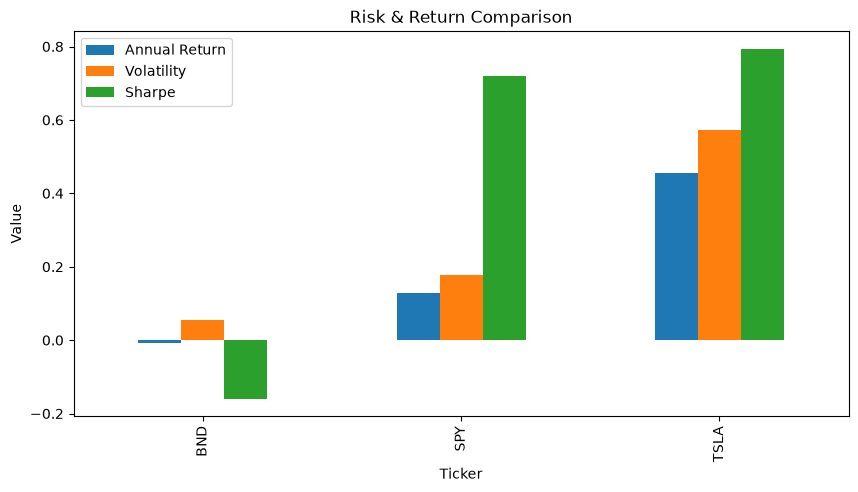

In [9]:
risk_df[["Annual Return", "Volatility", "Sharpe"]].plot(kind="bar", figsize=(10,5))
plt.title("Risk & Return Comparison")
plt.ylabel("Value")
plt.show()

Expected Results Interpretation
TSLA
Highest return
Highest volatility
Low Sharpe (risk-heavy asset)
SPY
Balanced return and risk
Benchmark performance
BND
Lowest return
Lowest volatility
Defensive asset